# 03 — Score distributions and independence from PSF size

Produces:
* **Table 2** (`tab:percentiles`) — shapelet-score percentiles per band and epoch.
* `fig/score_distribution.pdf` (`fig:dist`) — score distribution per band, both epochs.
* `fig/score_vs_fwhm.pdf` (`fig:fwhm`) — $i$-band score vs FWHM, showing the score is
  essentially independent of PSF size.

All scores are recomputed here from the stored `bvec` arrays using the paper's
definition (`ODD_ORDER`, odd $m$ with $n\geq3$). The `.npz` libraries are **not**
refitted.

In [1]:
import importlib.util
spec = importlib.util.spec_from_file_location('plot_config', 'plot_config.py')
plot_config = importlib.util.module_from_spec(spec); spec.loader.exec_module(plot_config)
from plot_config import (BANDS, BAND_COLORS, PALETTE, TIER_EDGES, TIER_COLORS, TIERS,
                         FIG, MultipleLocator, apply_style, bvec_path, shapelet_score,
                         classify_tier, FWHM_PER_SIGMA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import spearmanr

apply_style()
EPOCHS = {'DP2': 'dp2all', 'Post-DP2': 'postdp2'}
BAND_LABEL = 'i'          # band used for the FWHM figure

def load(band, tag):
    """Return (score, fwhm_arcsec, visit) for one band/epoch library."""
    d = np.load(bvec_path(band, tag))
    return (shapelet_score(d['bvec']),
            d['sigma'] * FWHM_PER_SIGMA,
            d['visit'])

data = {(e, b): load(b, t) for e, t in EPOCHS.items() for b in BANDS}
print({k: len(v[0]) for k, v in data.items()})

{('DP2', 'u'): 42698, ('DP2', 'g'): 88863, ('DP2', 'r'): 104521, ('DP2', 'i'): 164443, ('DP2', 'z'): 121771, ('DP2', 'y'): 90215, ('Post-DP2', 'u'): 28112, ('Post-DP2', 'g'): 58213, ('Post-DP2', 'r'): 105190, ('Post-DP2', 'i'): 341331, ('Post-DP2', 'z'): 187323, ('Post-DP2', 'y'): 135542}


## Table 2 — score percentiles

In [2]:
rows = []
for epoch in EPOCHS:
    for band in BANDS:
        s = data[(epoch, band)][0]
        rows.append(dict(epoch=epoch, band=band, n=len(s),
                         p50=np.percentile(s, 50), p80=np.percentile(s, 80),
                         p95=np.percentile(s, 95), p99=np.percentile(s, 99)))
perc = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.5f}')
print(perc.to_string(index=False))

print('\n--- where do the round tier edges fall, in percentile terms? ---')
for epoch in EPOCHS:
    s = np.concatenate([data[(epoch, b)][0] for b in BANDS])
    pcts = [(s < e).mean() * 100 for e in TIER_EDGES]
    print(f'{epoch:>9}: 0.002 -> P{pcts[0]:.1f}   0.005 -> P{pcts[1]:.1f}   '
          f'0.02 -> P{pcts[2]:.1f}   (N={len(s):,})')

print('\n--- tier occupancy, all bands pooled ---')
for epoch in EPOCHS:
    s = np.concatenate([data[(epoch, b)][0] for b in BANDS])
    t = classify_tier(s)
    frac = {name: (t == name).mean() * 100 for name, *_ in TIERS}
    print(f'{epoch:>9}: ' + '  '.join(f'{k}={v:.2f}%' for k, v in frac.items()))

   epoch band      n     p50     p80     p95     p99
     DP2    u  42698 0.00018 0.00053 0.00189 0.00681
     DP2    g  88863 0.00029 0.00088 0.00271 0.00902
     DP2    r 104521 0.00030 0.00100 0.00370 0.01272
     DP2    i 164443 0.00040 0.00151 0.00527 0.01479
     DP2    z 121771 0.00039 0.00145 0.00520 0.01597
     DP2    y  90215 0.00049 0.00179 0.00634 0.01715
Post-DP2    u  28112 0.00018 0.00047 0.00128 0.00301
Post-DP2    g  58213 0.00032 0.00101 0.00316 0.00867
Post-DP2    r 105190 0.00034 0.00112 0.00346 0.00891
Post-DP2    i 341331 0.00076 0.00218 0.00609 0.01658
Post-DP2    z 187323 0.00072 0.00216 0.00617 0.01548
Post-DP2    y 135542 0.00105 0.00312 0.00856 0.01860

--- where do the round tier edges fall, in percentile terms? ---
      DP2: 0.002 -> P87.1   0.005 -> P95.5   0.02 -> P99.5   (N=612,511)
 Post-DP2: 0.002 -> P79.6   0.005 -> P93.5   0.02 -> P99.4   (N=855,711)

--- tier occupancy, all bands pooled ---
      DP2: LOW=87.09%  MEDIUM=8.41%  HIGH=4.00%  VERY HIG

 Post-DP2: LOW=79.56%  MEDIUM=13.94%  HIGH=5.91%  VERY HIGH=0.60%


In [3]:
# LaTeX rows for Table 2
for epoch in EPOCHS:
    print(r'\multicolumn{6}{l}{\textit{' + epoch + r'}} \\')
    sub = perc[perc.epoch == epoch]
    for _, r in sub.iterrows():
        print(f"\\quad ${r['band']}$ & {int(r['n']):,} & {r['p50']:.5f} & {r['p80']:.5f} "
              f"& {r['p95']:.5f} & {r['p99']:.5f} " + r'\\')
    print(r'\addlinespace')

\multicolumn{6}{l}{\textit{DP2}} \\
\quad $u$ & 42,698 & 0.00018 & 0.00053 & 0.00189 & 0.00681 \\
\quad $g$ & 88,863 & 0.00029 & 0.00088 & 0.00271 & 0.00902 \\
\quad $r$ & 104,521 & 0.00030 & 0.00100 & 0.00370 & 0.01272 \\
\quad $i$ & 164,443 & 0.00040 & 0.00151 & 0.00527 & 0.01479 \\
\quad $z$ & 121,771 & 0.00039 & 0.00145 & 0.00520 & 0.01597 \\
\quad $y$ & 90,215 & 0.00049 & 0.00179 & 0.00634 & 0.01715 \\
\addlinespace
\multicolumn{6}{l}{\textit{Post-DP2}} \\
\quad $u$ & 28,112 & 0.00018 & 0.00047 & 0.00128 & 0.00301 \\
\quad $g$ & 58,213 & 0.00032 & 0.00101 & 0.00316 & 0.00867 \\
\quad $r$ & 105,190 & 0.00034 & 0.00112 & 0.00346 & 0.00891 \\
\quad $i$ & 341,331 & 0.00076 & 0.00218 & 0.00609 & 0.01658 \\
\quad $z$ & 187,323 & 0.00072 & 0.00216 & 0.00617 & 0.01548 \\
\quad $y$ & 135,542 & 0.00105 & 0.00312 & 0.00856 & 0.01860 \\
\addlinespace


## Figure: score distribution per band

wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_distribution.pdf


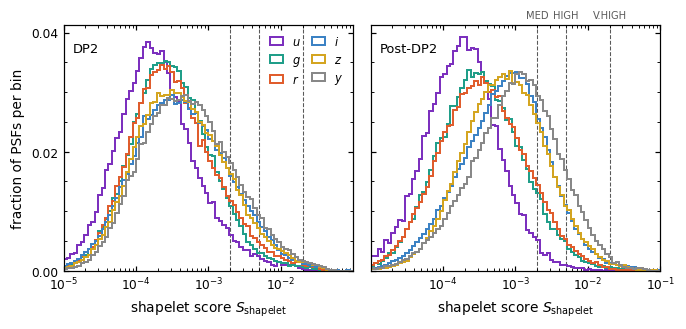

In [4]:
# Histogram in log-space: plot the FRACTION of PSFs per logarithmic bin.
# (density=True with log-spaced bins would give dN/dS, which is visually
#  dominated by the narrow low-score bins and misrepresents the shape.)
bins = np.logspace(-5, -1, 85)
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True,
                         gridspec_kw=dict(wspace=0.06))

for ax, (epoch, _) in zip(axes, EPOCHS.items()):
    for band in BANDS:
        s = data[(epoch, band)][0]
        s = s[s > 0]
        ax.hist(s, bins=bins, weights=np.full(len(s), 1.0 / len(s)),
                histtype='step', lw=1.3, color=BAND_COLORS[band], label=f'${band}$')
    for e in TIER_EDGES:
        ax.axvline(e, color='0.35', ls='--', lw=0.7, zorder=0)
    ax.set_xscale('log')
    ax.set_xlim(1e-5, 1e-1)
    ax.set_xlabel(r'shapelet score $S_{\rm shapelet}$')
    ax.text(0.03, 0.93, epoch, transform=ax.transAxes, va='top', fontsize=8.5)

axes[0].set_ylabel('fraction of PSFs per bin')
axes[0].legend(ncol=2, frameon=False, loc='upper right', fontsize=7.5,
               handlelength=1.1, columnspacing=1.0)
axes[0].yaxis.set_minor_locator(MultipleLocator(0.005))
axes[0].yaxis.set_major_locator(MultipleLocator(0.02))

# Stop the two panels' x tick labels from colliding at the shared edge.
axes[0].set_xticks([1e-5, 1e-4, 1e-3, 1e-2])
axes[1].set_xticks([1e-4, 1e-3, 1e-2, 1e-1])

for e, name in zip(TIER_EDGES, ['MED', 'HIGH', 'V.HIGH']):
    axes[1].text(e, 1.02, name, transform=axes[1].get_xaxis_transform(),
                 ha='center', va='bottom', fontsize=6.5, color='0.35')

fig.savefig(FIG / 'score_distribution.pdf')
print('wrote', FIG / 'score_distribution.pdf')

## Figure: score vs FWHM ($i$ band)

The key claim is that the score does **not** track PSF size. Quantify with the Pearson
and Spearman correlation, and with the running median of the score in FWHM bins.

In [5]:
from scipy.stats import spearmanr

print('correlation of score with FWHM')
for epoch in EPOCHS:
    for band in BANDS:
        s, f, _ = data[(epoch, band)]
        ok = np.isfinite(s) & np.isfinite(f) & (f > 0)
        r = np.corrcoef(s[ok], f[ok])[0, 1]
        rho = spearmanr(s[ok], f[ok]).statistic
        print(f'  {epoch:>9} {band}: pearson r = {r:+.3f}   spearman rho = {rho:+.3f}   N={ok.sum():,}')

correlation of score with FWHM
        DP2 u: pearson r = +0.181   spearman rho = +0.232   N=42,698
        DP2 g: pearson r = +0.151   spearman rho = +0.066   N=88,863
        DP2 r: pearson r = +0.184   spearman rho = +0.146   N=104,521
        DP2 i: pearson r = +0.152   spearman rho = -0.070   N=164,443
        DP2 z: pearson r = +0.137   spearman rho = -0.024   N=121,771
        DP2 y: pearson r = +0.103   spearman rho = -0.179   N=90,215
   Post-DP2 u: pearson r = -0.100   spearman rho = -0.299   N=28,112
   Post-DP2 g: pearson r = +0.195   spearman rho = -0.032   N=58,213
   Post-DP2 r: pearson r = -0.048   spearman rho = -0.284   N=105,190


   Post-DP2 i: pearson r = +0.110   spearman rho = -0.216   N=341,331
   Post-DP2 z: pearson r = +0.144   spearman rho = -0.048   N=187,323
   Post-DP2 y: pearson r = +0.158   spearman rho = +0.013   N=135,542


  DP2: pearson r = +0.152   spearman rho = -0.070


  Post-DP2: pearson r = +0.110   spearman rho = -0.216


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_vs_fwhm.pdf


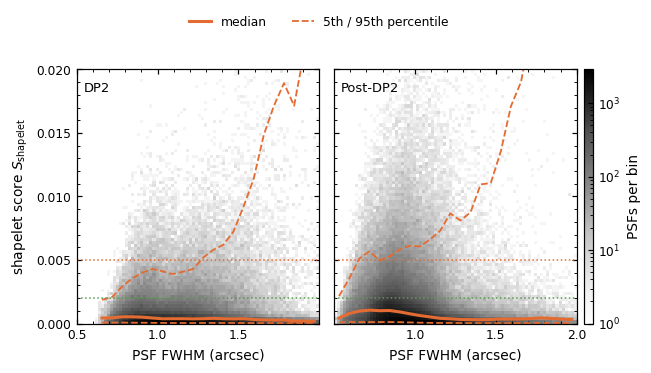

In [6]:
FW_RANGE = (0.5, 2.0)
SC_RANGE = (0.0, 0.02)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=True,
                         gridspec_kw=dict(wspace=0.06))

for ax, (epoch, _) in zip(axes, EPOCHS.items()):
    s, f, _ = data[(epoch, 'i')]
    ok = np.isfinite(s) & np.isfinite(f)
    h = ax.hist2d(f[ok], s[ok], bins=(80, 80), range=(FW_RANGE, SC_RANGE),
                  norm=LogNorm(), cmap='Greys')

    # Running percentiles of the score in FWHM bins. Drawn as lines, not a
    # filled band, so the underlying density stays visible.
    edges = np.linspace(*FW_RANGE, 25)
    mid = 0.5 * (edges[:-1] + edges[1:])
    stat = []
    for a, b in zip(edges[:-1], edges[1:]):
        m = ok & (f >= a) & (f < b)
        stat.append(np.percentile(s[m], [5, 50, 95]) if m.sum() > 50
                    else [np.nan] * 3)
    stat = np.array(stat)
    l95, = ax.plot(mid, stat[:, 2], color=PALETTE[0], lw=1.2, ls='--',
                   label='5th / 95th percentile')
    ax.plot(mid, stat[:, 0], color=PALETTE[0], lw=1.2, ls='--')
    lmed, = ax.plot(mid, stat[:, 1], color=PALETTE[0], lw=2.0, label='median')

    for e, name in zip(TIER_EDGES, ['MEDIUM', 'HIGH', 'VERY HIGH']):
        ax.axhline(e, color=TIER_COLORS[name], ls=':', lw=1.0)

    # The correlation with FWHM is well below |rho| = 0.3 in every band and
    # epoch, so the paper reports it qualitatively rather than as a number and
    # the panels carry only the epoch label. Values still printed below.
    r = np.corrcoef(s[ok], f[ok])[0, 1]
    rho = spearmanr(s[ok], f[ok]).statistic
    print(f'  {epoch}: pearson r = {r:+.3f}   spearman rho = {rho:+.3f}')
    ax.text(0.03, 0.95, epoch, transform=ax.transAxes, va='top', fontsize=8.5)
    ax.set_xlabel('PSF FWHM (arcsec)')
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.001))
    ax.yaxis.set_major_locator(MultipleLocator(0.005))

axes[0].set_xticks([0.5, 1.0, 1.5])          # avoid collision at the shared edge
axes[1].set_xticks([1.0, 1.5, 2.0])
axes[0].set_ylabel(r'shapelet score $S_{\rm shapelet}$')

# Figure-level legend above the panels, so it cannot collide with the
# annotations or with the rising 95th-percentile line.
fig.legend(handles=[lmed, l95], loc='lower center', ncol=2, frameon=False,
           fontsize=8, bbox_to_anchor=(0.44, 0.97), handlelength=1.8)
fig.colorbar(h[3], ax=axes, label='PSFs per bin', pad=0.012, aspect=28)

fig.savefig(FIG / 'score_vs_fwhm.pdf')
print('wrote', FIG / 'score_vs_fwhm.pdf')

In [7]:
# Numbers quoted in the text.
# The key point is not that the median is perfectly flat -- it is not -- but that
# the SCATTER at fixed FWHM is far larger than the variation of the median ACROSS
# FWHM. FWHM therefore carries almost no information about the score.
for epoch in EPOCHS:
    s, f, _ = data[(epoch, 'i')]
    ok = np.isfinite(s) & np.isfinite(f)
    edges = np.array([0.6, 0.8, 1.0, 1.2, 1.5])
    meds, spreads = [], []
    print(f'--- {epoch} ({BAND_LABEL}) ---')
    for a, b in zip(edges[:-1], edges[1:]):
        m = ok & (f >= a) & (f < b)
        p5, p50, p95 = np.percentile(s[m], [5, 50, 95])
        meds.append(p50); spreads.append(p95 / p5)
        print(f'  FWHM [{a},{b}): median={p50:.5f}  P5={p5:.5f}  P95={p95:.5f}  '
              f'P95/P5={p95/p5:.0f}x  N={m.sum():,}')
    print(f'  median varies by {max(meds)/min(meds):.1f}x across the FWHM range,')
    print(f'  while at fixed FWHM the 5-95 percentile span is '
          f'{np.mean(spreads):.0f}x on average.')

--- DP2 (i) ---
  FWHM [0.6,0.8): median=0.00050  P5=0.00008  P95=0.00259  P95/P5=34x  N=7,463
  FWHM [0.8,1.0): median=0.00049  P5=0.00006  P95=0.00399  P95/P5=68x  N=43,271
  FWHM [1.0,1.2): median=0.00038  P5=0.00004  P95=0.00402  P95/P5=96x  N=46,490
  FWHM [1.2,1.5): median=0.00038  P5=0.00004  P95=0.00558  P95/P5=138x  N=42,939
  median varies by 1.3x across the FWHM range,
  while at fixed FWHM the 5-95 percentile span is 84x on average.
--- Post-DP2 (i) ---
  FWHM [0.6,0.8): median=0.00101  P5=0.00011  P95=0.00523  P95/P5=46x  N=57,381
  FWHM [0.8,1.0): median=0.00092  P5=0.00010  P95=0.00563  P95/P5=55x  N=153,460
  FWHM [1.0,1.2): median=0.00054  P5=0.00005  P95=0.00652  P95/P5=122x  N=84,343
  FWHM [1.2,1.5): median=0.00033  P5=0.00003  P95=0.00907  P95/P5=272x  N=31,120
  median varies by 3.1x across the FWHM range,
  while at fixed FWHM the 5-95 percentile span is 124x on average.
